# Handwritten Digit Classification using MNIST Dataset

### Data Preparation for ANN training and classical ML models training

**importing required libraries**

In [28]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import torch
from torchvision import datasets
from torchvision import transforms

**Preparing the data for training the ANN**

- Now i have written code to convert images to tensors and then scale the pixel values between 0 and 1

- This scaling will be used during ANN training

In [11]:
transform_img = transforms.Compose([transforms.ToTensor()])

**Loading MNIST Dataset**

In [12]:
train_data = datasets.MNIST(
    root = './data', train=True, download= True, transform = transform_img
)

test_data = datasets.MNIST(
    root = './data', train = False, download= True, transform= transform_img
)

**Preparing the data for training classical ML models -- scaling**

- data converted to np array and float data type and then divided by 255 to scale b/w range [0,1]

In [13]:
X_train = train_data.data.numpy().astype(np.float32) / 255.0
X_test = test_data.data.numpy().astype(np.float32) / 255.0

- labels dont need to be scaled so they are converted to np array only

In [15]:
y_train = train_data.targets.numpy()
y_test = test_data.targets.numpy()

- flattening the np arrays

In [17]:
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)

In [18]:
X_train_flattened.shape, X_test_flattened.shape, y_train.shape, y_test.shape

((60000, 784), (10000, 784), (60000,), (10000,))

In [19]:
# the 28*28 pixels are now flattened to 784

In [20]:
# Checking if scaling has been done correctly

X_train_flattened.min(), X_train_flattened.max()

(np.float32(0.0), np.float32(1.0))

In [21]:
# values have been scaled b/w 0 and 1 for classical ml models

### Training the first classical ML model (Logistic Regression)

**importing required libraries**

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
model_logistic_regression = LogisticRegression(random_state=42, max_iter=300)

# Maximum iterations = 100 by default, but since its a image classification problem, identifying the patterns might take more iterations

In [24]:
# training -- 

model_logistic_regression.fit(X_train_flattened, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",300
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [25]:
# predicting --

predictions_logistic_reg = model_logistic_regression.predict(X_test_flattened)

**Evaluating the logistic regression model's performance**

In [26]:
accuracy = accuracy_score(y_test, predictions_logistic_reg)

print(f"Accuracy = {accuracy*100:.2f}%")

Accuracy = 92.68%


In [27]:
report = classification_report(y_test, predictions_logistic_reg)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



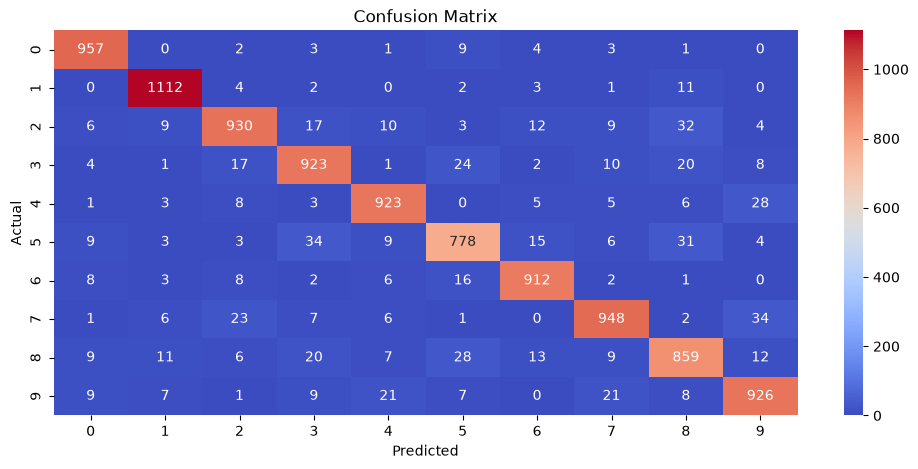

In [32]:
# plotting the confusion matrix 

plt.figure(figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, predictions_logistic_reg), annot=True, cmap='coolwarm', fmt = 'd')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### Observations from Logistic Regression Model --